# fintel — Financial Telemetry & Observability Package

## FE 520 Final Project | Spring 2026

---

### Overview

**fintel** is a Python package that applies **observability engineering concepts** — inspired by [OpenTelemetry](https://opentelemetry.io/) — to **stock market monitoring and analysis**.

In modern software engineering, OpenTelemetry is the industry standard for monitoring distributed systems. It provides three pillars of observability:
- **Traces & Spans** — discrete events with timing and metadata
- **Metrics** — numerical measurements aggregated over time windows
- **Alerts & SLOs** — threshold-based breach detection and service-level objectives

**fintel** asks: *What if we monitored stock portfolios the same way Site Reliability Engineers monitor production systems?*

### Package Modules

| Module | OTel Concept | Financial Application |
|---|---|---|
| `signals` | Traces & Spans | Anomaly detection — volatility spikes, volume surges, breakouts, gaps |
| `metrics` | Metric Instruments | Technical indicators with configurable time windows — SMA, EMA, RSI, Sharpe, etc. |
| `alerts` | Alerting & SLOs | Portfolio threshold rules and service-level objectives for risk management |
| `dashboard` | Grafana Dashboards | Multi-panel matplotlib visualizations with signal annotations and health gauges |

### Target Audience
Quantitative analysts, portfolio managers, and fintech developers who want a structured, observability-first approach to monitoring financial instruments.

### Allowed Packages Used
- **pandas** — DataFrame operations, time series handling
- **numpy** — numerical computations, statistical functions
- **matplotlib** — all visualizations and dashboard rendering
- **datetime** — date/time manipulation for signals and alert timestamps
- **yfinance** — live stock data retrieval

---
## Installation & Quick Start

### 1.1  Requirements

`fintel` is intentionally constrained to the five libraries permitted by FE 520. Any modern Python environment (3.8 or newer) that has these installed will run the package without further dependencies.

| Library | Minimum version | Purpose in `fintel` |
|---|---|---|
| pandas | 1.5 | DataFrame and time-series operations |
| numpy | 1.22 | Numerical computations, statistical functions |
| matplotlib | 3.5 | All visualization and dashboard rendering |
| yfinance | 0.2 | Live OHLCV data ingestion |
| Python `datetime` | stdlib | Timestamps for signals and alerts |

### 1.2  Installation

The package ships as a single Jupyter notebook (this file) and as an installable Python package in the companion `fintel/` directory.

**Option A — run inside this notebook (recommended for grading):** simply execute the cells in order. No `pip install` is required because every class is defined inline in Section 2 onwards.

**Option B — install as a local package:**
```bash
cd /path/to/fintel
pip install -e .
```

After installation you can import from anywhere:
```python
from fintel import (
    SignalDetector, MetricsEngine, AlertEngine, SLO, Dashboard,
    DataValidationError, InsufficientDataError, InvalidParameterError,
)
```

**Option C — install runtime dependencies only:**
```bash
pip install pandas numpy matplotlib yfinance
```

### 1.3  Quick Start (60 seconds)

A complete end-to-end run in five lines:

```python
import yfinance as yf
data = yf.download("AAPL", period="1y", progress=False)

me = MetricsEngine(data)
print(me.compute_summary())                       # one-shot metric report

signals = SignalDetector(data, "AAPL").get_all_signals()
print(f"Detected {len(signals)} signals")
```

That single block ingests data, computes every supported metric, runs every signal detector, and reports the totals. Building a full dashboard is one more line:

```python
Dashboard("AAPL", data, me, signals=signals).render()
```

### 1.4  Reading This Notebook

The remainder of the notebook is organised as follows:

| Section | Contents |
|---|---|
| 2 | Package core — exception hierarchy and validation utilities |
| 3 | Module I — `SignalDetector` |
| 4 | Module II — `MetricsEngine` |
| 5 | Module III — `AlertEngine` and `SLO` |
| 6 | Module IV — `Dashboard` |
| 7 | Test suite — happy path and failure mode |
| 7 | **Examples & Use Cases** — five focused worked examples |
| 8 | Full demonstration — live AAPL / GOOGL / MSFT analysis |
| 9 | Conclusion, design decisions, and challenges |


---
## Section 1: Imports and Package Core

We begin by importing the five allowed packages and defining our custom exception hierarchy. Following Python best practices, we define a base exception `FintelError` with specific subclasses for different failure modes.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from datetime import datetime, timedelta
import yfinance as yf

# Package metadata
__version__ = "1.0.0"
__author__ = "fintel team"

print(f"fintel v{__version__} loaded successfully.")
print(f"pandas={pd.__version__}, numpy={np.__version__}, matplotlib={plt.matplotlib.__version__}")

fintel v1.0.0 loaded successfully.
pandas=2.3.3, numpy=2.0.2, matplotlib=3.9.4


/Users/maru/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [4]:
# =============================================================================
# Custom Exception Hierarchy
# =============================================================================

class FintelError(Exception):
    """Base exception for all fintel package errors."""
    pass


class DataValidationError(FintelError):
    """Raised when input data does not meet expected schema (missing columns, wrong types)."""
    pass


class InsufficientDataError(FintelError):
    """Raised when there are not enough data points for the requested computation."""
    pass


class InvalidParameterError(FintelError):
    """Raised when a function parameter is out of valid range."""
    pass


# =============================================================================
# Data Validation Utility
# =============================================================================

REQUIRED_COLUMNS = ["Open", "High", "Low", "Close", "Volume"]


def validate_ohlcv(data):
    """Validate that input is a DataFrame with required OHLCV columns.
    
    Parameters
    ----------
    data : pd.DataFrame
        DataFrame to validate.
    
    Raises
    ------
    DataValidationError
        If data is not a DataFrame, is empty, or lacks required columns.
    """
    if not isinstance(data, pd.DataFrame):
        raise DataValidationError(
            f"Expected pd.DataFrame, got {type(data).__name__}"
        )
    if data.empty:
        raise DataValidationError("DataFrame is empty. Cannot perform analysis on empty data.")
    
    # Handle multi-level columns from yfinance
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)
    
    missing = [col for col in REQUIRED_COLUMNS if col not in data.columns]
    if missing:
        raise DataValidationError(
            f"Missing required columns: {missing}. "
            f"Expected OHLCV columns: {REQUIRED_COLUMNS}"
        )
    
    # Check for numeric types
    for col in REQUIRED_COLUMNS:
        if not np.issubdtype(data[col].dtype, np.number):
            raise DataValidationError(
                f"Column '{col}' must be numeric, got {data[col].dtype}"
            )


def validate_positive_int(value, name):
    """Validate that a parameter is a positive integer."""
    if not isinstance(value, (int, np.integer)):
        raise InvalidParameterError(f"{name} must be an integer, got {type(value).__name__}")
    if value <= 0:
        raise InvalidParameterError(f"{name} must be positive, got {value}")


def validate_positive_float(value, name):
    """Validate that a parameter is a positive number."""
    if not isinstance(value, (int, float, np.integer, np.floating)):
        raise InvalidParameterError(f"{name} must be a number, got {type(value).__name__}")
    if value <= 0:
        raise InvalidParameterError(f"{name} must be positive, got {value}")


print("Core utilities and exceptions defined.")

Core utilities and exceptions defined.


---
## Section 2: Module 1 — Signal Detection Engine (`signals`)

### OpenTelemetry Inspiration: Traces & Spans

In OpenTelemetry, a **trace** represents a complete request path through a distributed system, composed of individual **spans** — discrete events with a start time, end time, severity, and metadata.

In **fintel**, we apply this concept to financial data: each detected market anomaly (a volatility spike, volume surge, price breakout, or gap event) is represented as a **Signal** — an object with timing, classification, severity level, and contextual metadata.

The `SignalDetector` class scans OHLCV data and emits Signals whenever statistical thresholds are breached, providing a structured event log of market behavior.

In [5]:
# =============================================================================
# Module 1: Signal Detection Engine
# =============================================================================

class Signal:
    """Represents a detected market event, analogous to an OpenTelemetry Span.
    
    Attributes
    ----------
    ticker : str
        Stock ticker symbol.
    signal_type : str
        Type of signal (e.g., 'volatility_spike', 'volume_surge').
    timestamp : datetime
        When the signal was detected.
    severity : str
        One of 'info', 'warning', 'critical'.
    value : float
        The observed value that triggered the signal.
    threshold : float
        The threshold that was breached.
    metadata : dict
        Additional context about the signal.
    """
    
    VALID_SEVERITIES = ("info", "warning", "critical")
    
    def __init__(self, ticker, signal_type, timestamp, severity, value, threshold, metadata=None):
        if severity not in self.VALID_SEVERITIES:
            raise InvalidParameterError(
                f"severity must be one of {self.VALID_SEVERITIES}, got '{severity}'"
            )
        self.ticker = str(ticker)
        self.signal_type = str(signal_type)
        self.timestamp = timestamp
        self.severity = severity
        self.value = float(value)
        self.threshold = float(threshold)
        self.metadata = metadata or {}
    
    def __repr__(self):
        return (
            f"Signal({self.ticker} | {self.signal_type} | "
            f"{self.severity.upper()} | {self.timestamp.strftime('%Y-%m-%d')} | "
            f"value={self.value:.4f}, threshold={self.threshold:.4f})"
        )
    
    def to_dict(self):
        """Convert signal to a dictionary for DataFrame creation."""
        return {
            "ticker": self.ticker,
            "signal_type": self.signal_type,
            "timestamp": self.timestamp,
            "severity": self.severity,
            "value": self.value,
            "threshold": self.threshold,
            "metadata": str(self.metadata)
        }


class SignalDetector:
    """Scans OHLCV data for market anomalies and emits Signal objects.
    
    Analogous to an OpenTelemetry TracerProvider that generates spans
    for notable events in a distributed system.
    
    Parameters
    ----------
    data : pd.DataFrame
        OHLCV DataFrame with DatetimeIndex.
    ticker : str
        Ticker symbol for labeling signals.
    
    Examples
    --------
    >>> detector = SignalDetector(data, ticker='AAPL')
    >>> signals = detector.detect_volatility_spikes(threshold_std=2.0)
    >>> print(f'Found {len(signals)} volatility spikes')
    """
    
    def __init__(self, data, ticker="UNKNOWN"):
        try:
            validate_ohlcv(data)
        except DataValidationError:
            raise
        except Exception as e:
            raise DataValidationError(f"Unexpected error validating data: {e}")
        
        self.data = data.copy()
        self.ticker = str(ticker)
        self._signals = []
    
    def detect_volatility_spikes(self, window=20, threshold_std=2.0):
        """Detect periods where rolling volatility exceeds a threshold.
        
        Parameters
        ----------
        window : int
            Rolling window size for volatility calculation.
        threshold_std : float
            Number of standard deviations above mean volatility to trigger.
        
        Returns
        -------
        list of Signal
        """
        try:
            validate_positive_int(window, "window")
            validate_positive_float(threshold_std, "threshold_std")
        except InvalidParameterError:
            raise
        
        if len(self.data) < window:
            raise InsufficientDataError(
                f"Need at least {window} data points, have {len(self.data)}"
            )
        
        returns = self.data["Close"].pct_change().dropna()
        rolling_vol = returns.rolling(window=window).std()
        mean_vol = rolling_vol.mean()
        std_vol = rolling_vol.std()
        threshold = mean_vol + threshold_std * std_vol
        
        signals = []
        spike_mask = rolling_vol > threshold
        
        for date in rolling_vol[spike_mask].index:
            vol_val = rolling_vol.loc[date]
            severity = "critical" if vol_val > mean_vol + 3 * std_vol else "warning"
            sig = Signal(
                ticker=self.ticker,
                signal_type="volatility_spike",
                timestamp=date,
                severity=severity,
                value=vol_val,
                threshold=threshold,
                metadata={"window": window, "mean_vol": round(mean_vol, 6)}
            )
            signals.append(sig)
        
        self._signals.extend(signals)
        return signals
    
    def detect_volume_surges(self, window=20, threshold_multiplier=2.0):
        """Detect days where volume exceeds a multiple of the rolling average.
        
        Parameters
        ----------
        window : int
            Rolling window for average volume.
        threshold_multiplier : float
            Multiple of average volume to trigger signal.
        
        Returns
        -------
        list of Signal
        """
        try:
            validate_positive_int(window, "window")
            validate_positive_float(threshold_multiplier, "threshold_multiplier")
        except InvalidParameterError:
            raise
        
        if len(self.data) < window:
            raise InsufficientDataError(
                f"Need at least {window} data points, have {len(self.data)}"
            )
        
        avg_volume = self.data["Volume"].rolling(window=window).mean()
        threshold = avg_volume * threshold_multiplier
        
        signals = []
        surge_mask = self.data["Volume"] > threshold
        # Skip the first `window` rows where rolling avg is NaN
        surge_mask = surge_mask & avg_volume.notna()
        
        for date in self.data[surge_mask].index:
            vol = self.data.loc[date, "Volume"]
            avg = avg_volume.loc[date]
            multiplier = vol / avg if avg > 0 else 0
            severity = "critical" if multiplier > 3.0 else "warning"
            
            sig = Signal(
                ticker=self.ticker,
                signal_type="volume_surge",
                timestamp=date,
                severity=severity,
                value=vol,
                threshold=threshold.loc[date],
                metadata={"multiplier": round(multiplier, 2), "avg_volume": round(avg, 0)}
            )
            signals.append(sig)
        
        self._signals.extend(signals)
        return signals
    
    def detect_price_breakouts(self, window=20, num_std=2.0):
        """Detect when price breaks above/below Bollinger Bands.
        
        Parameters
        ----------
        window : int
            Bollinger Band window.
        num_std : float
            Number of standard deviations for bands.
        
        Returns
        -------
        list of Signal
        """
        try:
            validate_positive_int(window, "window")
            validate_positive_float(num_std, "num_std")
        except InvalidParameterError:
            raise
        
        if len(self.data) < window:
            raise InsufficientDataError(
                f"Need at least {window} data points, have {len(self.data)}"
            )
        
        close = self.data["Close"]
        sma = close.rolling(window=window).mean()
        std = close.rolling(window=window).std()
        upper = sma + num_std * std
        lower = sma - num_std * std
        
        signals = []
        valid_idx = sma.dropna().index
        
        for date in valid_idx:
            price = close.loc[date]
            if price > upper.loc[date]:
                sig = Signal(
                    ticker=self.ticker,
                    signal_type="breakout_upper",
                    timestamp=date,
                    severity="warning",
                    value=price,
                    threshold=upper.loc[date],
                    metadata={"band": "upper", "sma": round(sma.loc[date], 2)}
                )
                signals.append(sig)
            elif price < lower.loc[date]:
                sig = Signal(
                    ticker=self.ticker,
                    signal_type="breakout_lower",
                    timestamp=date,
                    severity="critical",
                    value=price,
                    threshold=lower.loc[date],
                    metadata={"band": "lower", "sma": round(sma.loc[date], 2)}
                )
                signals.append(sig)
        
        self._signals.extend(signals)
        return signals
    
    def detect_gap_events(self, min_gap_pct=2.0):
        """Detect opening gaps (price jumps between previous close and current open).
        
        Parameters
        ----------
        min_gap_pct : float
            Minimum gap percentage to trigger a signal.
        
        Returns
        -------
        list of Signal
        """
        try:
            validate_positive_float(min_gap_pct, "min_gap_pct")
        except InvalidParameterError:
            raise
        
        if len(self.data) < 2:
            raise InsufficientDataError("Need at least 2 data points to detect gaps.")
        
        prev_close = self.data["Close"].shift(1)
        current_open = self.data["Open"]
        gap_pct = ((current_open - prev_close) / prev_close * 100).dropna()
        
        signals = []
        for date in gap_pct.index:
            gap = gap_pct.loc[date]
            if abs(gap) >= min_gap_pct:
                direction = "gap_up" if gap > 0 else "gap_down"
                severity = "critical" if abs(gap) >= 2 * min_gap_pct else "warning"
                sig = Signal(
                    ticker=self.ticker,
                    signal_type=direction,
                    timestamp=date,
                    severity=severity,
                    value=abs(gap),
                    threshold=min_gap_pct,
                    metadata={"gap_pct": round(gap, 2), "direction": direction}
                )
                signals.append(sig)
        
        self._signals.extend(signals)
        return signals
    
    def get_all_signals(self, window=20, threshold_std=2.0, threshold_multiplier=2.0,
                        num_std=2.0, min_gap_pct=2.0):
        """Run all detection methods and return combined, time-sorted signals.
        
        Returns
        -------
        list of Signal
            All detected signals sorted by timestamp.
        """
        self._signals = []  # Reset
        self.detect_volatility_spikes(window=window, threshold_std=threshold_std)
        self.detect_volume_surges(window=window, threshold_multiplier=threshold_multiplier)
        self.detect_price_breakouts(window=window, num_std=num_std)
        self.detect_gap_events(min_gap_pct=min_gap_pct)
        
        self._signals.sort(key=lambda s: s.timestamp)
        return self._signals
    
    def signals_to_dataframe(self):
        """Convert all detected signals to a pandas DataFrame."""
        if not self._signals:
            return pd.DataFrame(columns=["ticker", "signal_type", "timestamp",
                                          "severity", "value", "threshold", "metadata"])
        return pd.DataFrame([s.to_dict() for s in self._signals])


print("Module 1 (signals) defined: Signal, SignalDetector")

Module 1 (signals) defined: Signal, SignalDetector


---
## Section 3: Module 2 — Financial Metrics Engine (`metrics`)

### OpenTelemetry Inspiration: Metric Instruments

In OpenTelemetry, **metrics** are numerical measurements collected at regular intervals and aggregated over configurable time windows (e.g., request latency over 5-minute windows, error rates per hour).

In **fintel**, the `MetricsEngine` computes financial technical indicators using the same paradigm: rolling time windows, configurable aggregation periods, and structured output. Each metric is computed lazily and cached, just like an OTel metric instrument that only calculates when observed.

In [6]:
# =============================================================================
# Module 2: Financial Metrics Engine
# =============================================================================

class MetricsEngine:
    """Compute and cache financial metrics over configurable time windows.
    
    Analogous to an OpenTelemetry MeterProvider that exposes metric instruments
    (counters, gauges, histograms) for a monitored system.
    
    Parameters
    ----------
    data : pd.DataFrame
        OHLCV DataFrame with DatetimeIndex.
    
    Examples
    --------
    >>> engine = MetricsEngine(data)
    >>> sma_20 = engine.sma(window=20)
    >>> sharpe = engine.sharpe_ratio()
    """
    
    def __init__(self, data):
        try:
            validate_ohlcv(data)
        except DataValidationError:
            raise
        except Exception as e:
            raise DataValidationError(f"Unexpected error validating data: {e}")
        
        self.data = data.copy()
        self._cache = {}  # Cache computed metrics
    
    def _check_window(self, window, name="window"):
        """Validate window size against available data."""
        validate_positive_int(window, name)
        if len(self.data) < window:
            raise InsufficientDataError(
                f"Need at least {window} data points for {name}={window}, "
                f"have {len(self.data)}"
            )
    
    def daily_returns(self):
        """Compute daily percentage returns.
        
        Returns
        -------
        pd.Series
            Daily returns as decimal fractions.
        """
        if "daily_returns" not in self._cache:
            self._cache["daily_returns"] = self.data["Close"].pct_change().dropna()
        return self._cache["daily_returns"]
    
    def sma(self, window=20):
        """Simple Moving Average.
        
        Parameters
        ----------
        window : int
            Number of periods.
        
        Returns
        -------
        pd.Series
        """
        self._check_window(window)
        key = f"sma_{window}"
        if key not in self._cache:
            self._cache[key] = self.data["Close"].rolling(window=window).mean()
        return self._cache[key]
    
    def ema(self, window=20):
        """Exponential Moving Average.
        
        Parameters
        ----------
        window : int
            Span for EMA calculation.
        
        Returns
        -------
        pd.Series
        """
        self._check_window(window)
        key = f"ema_{window}"
        if key not in self._cache:
            self._cache[key] = self.data["Close"].ewm(span=window, adjust=False).mean()
        return self._cache[key]
    
    def bollinger_bands(self, window=20, num_std=2.0):
        """Bollinger Bands (upper, middle, lower).
        
        Parameters
        ----------
        window : int
            Rolling window size.
        num_std : float
            Number of standard deviations for bands.
        
        Returns
        -------
        tuple of (pd.Series, pd.Series, pd.Series)
            Upper band, middle (SMA), lower band.
        """
        self._check_window(window)
        validate_positive_float(num_std, "num_std")
        
        middle = self.sma(window)
        std = self.data["Close"].rolling(window=window).std()
        upper = middle + num_std * std
        lower = middle - num_std * std
        return upper, middle, lower
    
    def rsi(self, window=14):
        """Relative Strength Index.
        
        Parameters
        ----------
        window : int
            RSI lookback period.
        
        Returns
        -------
        pd.Series
            RSI values between 0 and 100.
        """
        self._check_window(window)
        key = f"rsi_{window}"
        if key not in self._cache:
            delta = self.data["Close"].diff()
            gain = delta.where(delta > 0, 0.0)
            loss = (-delta).where(delta < 0, 0.0)
            
            avg_gain = gain.rolling(window=window).mean()
            avg_loss = loss.rolling(window=window).mean()
            
            # Avoid division by zero
            rs = np.where(avg_loss != 0, avg_gain / avg_loss, 100.0)
            rsi_values = 100 - (100 / (1 + rs))
            self._cache[key] = pd.Series(rsi_values, index=self.data.index, name="RSI")
        return self._cache[key]
    
    def rolling_volatility(self, window=20):
        """Rolling annualized volatility.
        
        Parameters
        ----------
        window : int
            Rolling window size.
        
        Returns
        -------
        pd.Series
            Annualized rolling volatility.
        """
        self._check_window(window)
        key = f"vol_{window}"
        if key not in self._cache:
            returns = self.daily_returns()
            self._cache[key] = returns.rolling(window=window).std() * np.sqrt(252)
        return self._cache[key]
    
    def sharpe_ratio(self, risk_free_rate=0.02, period=252):
        """Annualized Sharpe Ratio.
        
        Parameters
        ----------
        risk_free_rate : float
            Annual risk-free rate (default 2%).
        period : int
            Trading days per year.
        
        Returns
        -------
        float
            Annualized Sharpe ratio.
        """
        if not isinstance(risk_free_rate, (int, float)):
            raise InvalidParameterError(
                f"risk_free_rate must be a number, got {type(risk_free_rate).__name__}"
            )
        
        returns = self.daily_returns()
        if len(returns) == 0:
            raise InsufficientDataError("No return data available for Sharpe ratio.")
        
        excess_returns = returns - risk_free_rate / period
        std = excess_returns.std()
        
        if std == 0:
            return 0.0  # No volatility means no risk-adjusted return
        
        return float((excess_returns.mean() / std) * np.sqrt(period))
    
    def max_drawdown(self):
        """Maximum Drawdown — the largest peak-to-trough decline.
        
        Returns
        -------
        dict
            Contains 'max_drawdown' (float), 'peak_date', 'trough_date'.
        """
        close = self.data["Close"]
        cumulative_max = close.cummax()
        drawdown = (close - cumulative_max) / cumulative_max
        
        max_dd = drawdown.min()
        trough_date = drawdown.idxmin()
        peak_date = close.loc[:trough_date].idxmax()
        
        return {
            "max_drawdown": float(max_dd),
            "peak_date": peak_date,
            "trough_date": trough_date
        }
    
    def compute_summary(self):
        """Compute a summary dictionary of key metrics.
        
        Returns
        -------
        dict
            Summary of all major metrics.
        """
        dd = self.max_drawdown()
        latest_rsi = self.rsi().dropna()
        latest_rsi_val = float(latest_rsi.iloc[-1]) if len(latest_rsi) > 0 else None
        
        return {
            "latest_close": float(self.data["Close"].iloc[-1]),
            "sma_20": float(self.sma(20).iloc[-1]) if len(self.data) >= 20 else None,
            "ema_20": float(self.ema(20).iloc[-1]) if len(self.data) >= 20 else None,
            "rsi_14": latest_rsi_val,
            "sharpe_ratio": self.sharpe_ratio(),
            "max_drawdown": dd["max_drawdown"],
            "max_drawdown_peak": str(dd["peak_date"].date()) if hasattr(dd["peak_date"], 'date') else str(dd["peak_date"]),
            "max_drawdown_trough": str(dd["trough_date"].date()) if hasattr(dd["trough_date"], 'date') else str(dd["trough_date"]),
            "annualized_volatility": float(self.rolling_volatility(20).iloc[-1]) if len(self.data) >= 20 else None,
            "total_return": float((self.data["Close"].iloc[-1] / self.data["Close"].iloc[0]) - 1)
        }


print("Module 2 (metrics) defined: MetricsEngine")

Module 2 (metrics) defined: MetricsEngine


---
## Section 4: Module 3 — Alert & SLO Engine (`alerts`)

### OpenTelemetry Inspiration: Alerting Rules & Service Level Objectives

In production systems, **alerting rules** define conditions that trigger notifications — e.g., "alert if p99 latency exceeds 500ms for 5 minutes." **SLOs** (Service Level Objectives) define reliability targets — e.g., "99.9% of requests must succeed."

In **fintel**, we apply the same pattern to portfolios:
- **AlertRule**: "Alert if RSI drops below 30" or "Alert if drawdown exceeds 15%"
- **SLO**: "Portfolio Sharpe ratio must stay above 1.0 over any 60-day window"

The `AlertEngine` evaluates rules against live `MetricsEngine` data and produces structured alerts.

In [7]:
# =============================================================================
# Module 3: Alert & SLO Engine
# =============================================================================

class AlertRule:
    """Defines a threshold-based alert condition.
    
    Attributes
    ----------
    name : str
        Human-readable rule name.
    metric_name : str
        Which metric to evaluate (must match a MetricsEngine method).
    condition : str
        'above' or 'below'.
    threshold : float
        The numeric threshold.
    severity : str
        'info', 'warning', or 'critical'.
    """
    
    VALID_CONDITIONS = ("above", "below")
    VALID_SEVERITIES = ("info", "warning", "critical")
    
    def __init__(self, name, metric_name, condition, threshold, severity="warning"):
        if not isinstance(name, str) or not name.strip():
            raise InvalidParameterError("Rule name must be a non-empty string.")
        if condition not in self.VALID_CONDITIONS:
            raise InvalidParameterError(
                f"condition must be one of {self.VALID_CONDITIONS}, got '{condition}'"
            )
        if severity not in self.VALID_SEVERITIES:
            raise InvalidParameterError(
                f"severity must be one of {self.VALID_SEVERITIES}, got '{severity}'"
            )
        if not isinstance(threshold, (int, float)):
            raise InvalidParameterError(
                f"threshold must be a number, got {type(threshold).__name__}"
            )
        
        self.name = name.strip()
        self.metric_name = str(metric_name)
        self.condition = condition
        self.threshold = float(threshold)
        self.severity = severity
    
    def __repr__(self):
        return f"AlertRule('{self.name}': {self.metric_name} {self.condition} {self.threshold})"


class Alert:
    """A triggered alert — the result of evaluating an AlertRule."""
    
    def __init__(self, rule, triggered_at, current_value, message):
        self.rule = rule
        self.triggered_at = triggered_at
        self.current_value = current_value
        self.message = message
    
    def __repr__(self):
        return (
            f"Alert [{self.rule.severity.upper()}] {self.rule.name}: "
            f"{self.message} (value={self.current_value:.4f})"
        )


class AlertEngine:
    """Evaluates alert rules against a MetricsEngine and produces triggered alerts.
    
    Analogous to an OpenTelemetry alert manager that evaluates rules
    against collected metrics and fires notifications.
    
    Examples
    --------
    >>> engine = AlertEngine()
    >>> engine.add_rule('RSI Oversold', 'rsi', 'below', 30, 'critical')
    >>> alerts = engine.evaluate(metrics_engine)
    """
    
    # Maps rule metric_name to how we extract a scalar from MetricsEngine
    METRIC_EXTRACTORS = {
        "rsi": lambda me: float(me.rsi().dropna().iloc[-1]),
        "sharpe_ratio": lambda me: me.sharpe_ratio(),
        "max_drawdown": lambda me: me.max_drawdown()["max_drawdown"],
        "volatility": lambda me: float(me.rolling_volatility().dropna().iloc[-1]),
        "sma_20": lambda me: float(me.sma(20).dropna().iloc[-1]),
        "ema_20": lambda me: float(me.ema(20).dropna().iloc[-1]),
        "daily_return": lambda me: float(me.daily_returns().iloc[-1]),
        "total_return": lambda me: float(
            (me.data["Close"].iloc[-1] / me.data["Close"].iloc[0]) - 1
        ),
        "latest_close": lambda me: float(me.data["Close"].iloc[-1]),
    }
    
    def __init__(self):
        self._rules = {}  # name -> AlertRule
        self._triggered = []  # list of Alert
    
    def add_rule(self, name, metric_name, condition, threshold, severity="warning"):
        """Register an alert rule.
        
        Parameters
        ----------
        name : str
            Unique rule name.
        metric_name : str
            Metric to evaluate (see METRIC_EXTRACTORS for valid names).
        condition : str
            'above' or 'below'.
        threshold : float
            Numeric threshold.
        severity : str
            'info', 'warning', or 'critical'.
        
        Raises
        ------
        InvalidParameterError
            If name already exists or metric_name is unknown.
        """
        if name in self._rules:
            raise InvalidParameterError(f"Rule '{name}' already exists. Use remove_rule() first.")
        if metric_name not in self.METRIC_EXTRACTORS:
            raise InvalidParameterError(
                f"Unknown metric '{metric_name}'. "
                f"Valid metrics: {list(self.METRIC_EXTRACTORS.keys())}"
            )
        
        rule = AlertRule(name, metric_name, condition, threshold, severity)
        self._rules[name] = rule
        return rule
    
    def remove_rule(self, name):
        """Remove a rule by name.
        
        Raises
        ------
        InvalidParameterError
            If rule does not exist.
        """
        if name not in self._rules:
            raise InvalidParameterError(
                f"Rule '{name}' not found. Existing rules: {list(self._rules.keys())}"
            )
        del self._rules[name]
    
    def evaluate(self, metrics_engine):
        """Evaluate all rules against a MetricsEngine.
        
        Parameters
        ----------
        metrics_engine : MetricsEngine
            The metrics source to evaluate against.
        
        Returns
        -------
        list of Alert
            All triggered alerts.
        """
        if not isinstance(metrics_engine, MetricsEngine):
            raise DataValidationError(
                f"Expected MetricsEngine, got {type(metrics_engine).__name__}"
            )
        
        self._triggered = []
        now = datetime.now()
        
        for name, rule in self._rules.items():
            try:
                extractor = self.METRIC_EXTRACTORS[rule.metric_name]
                current_value = extractor(metrics_engine)
            except (IndexError, KeyError, InsufficientDataError) as e:
                # Skip rules that can't be evaluated due to insufficient data
                continue
            except Exception as e:
                continue
            
            triggered = False
            if rule.condition == "above" and current_value > rule.threshold:
                triggered = True
            elif rule.condition == "below" and current_value < rule.threshold:
                triggered = True
            
            if triggered:
                msg = (
                    f"{rule.metric_name} is {current_value:.4f}, "
                    f"which is {rule.condition} threshold {rule.threshold}"
                )
                alert = Alert(rule, now, current_value, msg)
                self._triggered.append(alert)
        
        return self._triggered
    
    def summary(self):
        """Return a formatted summary of all triggered alerts."""
        if not self._triggered:
            return "No alerts triggered. All systems nominal."
        
        lines = [f"=== ALERT SUMMARY ({len(self._triggered)} triggered) ==="]
        for alert in self._triggered:
            icon = {"critical": "[!!!]", "warning": "[!!]", "info": "[i]"}[alert.rule.severity]
            lines.append(f"  {icon} {alert.rule.name}: {alert.message}")
        return "\n".join(lines)
    
    def get_rules(self):
        """Return a list of all registered rules."""
        return list(self._rules.values())


class SLO:
    """Service Level Objective for a financial portfolio.
    
    Defines a reliability/performance target and checks whether
    the portfolio meets it, reporting error budget remaining.
    
    Parameters
    ----------
    name : str
        SLO name.
    target_metric : str
        Metric to evaluate.
    condition : str
        'above' or 'below'.
    target_value : float
        The SLO target.
    
    Examples
    --------
    >>> slo = SLO('Min Sharpe', 'sharpe_ratio', 'above', 1.0)
    >>> result = slo.check(metrics_engine)
    """
    
    def __init__(self, name, target_metric, condition, target_value):
        if not isinstance(name, str) or not name.strip():
            raise InvalidParameterError("SLO name must be a non-empty string.")
        if condition not in ("above", "below"):
            raise InvalidParameterError(f"condition must be 'above' or 'below', got '{condition}'")
        if target_metric not in AlertEngine.METRIC_EXTRACTORS:
            raise InvalidParameterError(
                f"Unknown metric '{target_metric}'. "
                f"Valid: {list(AlertEngine.METRIC_EXTRACTORS.keys())}"
            )
        if not isinstance(target_value, (int, float)):
            raise InvalidParameterError(
                f"target_value must be a number, got {type(target_value).__name__}"
            )
        
        self.name = name.strip()
        self.target_metric = target_metric
        self.condition = condition
        self.target_value = float(target_value)
    
    def check(self, metrics_engine):
        """Check if the SLO is met.
        
        Parameters
        ----------
        metrics_engine : MetricsEngine
        
        Returns
        -------
        dict
            'met' (bool), 'current_value' (float), 'target' (float), 'margin' (float).
        """
        if not isinstance(metrics_engine, MetricsEngine):
            raise DataValidationError(
                f"Expected MetricsEngine, got {type(metrics_engine).__name__}"
            )
        
        try:
            extractor = AlertEngine.METRIC_EXTRACTORS[self.target_metric]
            current = extractor(metrics_engine)
        except Exception as e:
            raise FintelError(f"Could not evaluate SLO '{self.name}': {e}")
        
        if self.condition == "above":
            met = current >= self.target_value
            margin = current - self.target_value
        else:
            met = current <= self.target_value
            margin = self.target_value - current
        
        return {
            "slo_name": self.name,
            "met": met,
            "current_value": current,
            "target": self.target_value,
            "margin": margin,
            "status": "PASS" if met else "FAIL"
        }
    
    def __repr__(self):
        return f"SLO('{self.name}': {self.target_metric} {self.condition} {self.target_value})"


print("Module 3 (alerts) defined: AlertRule, Alert, AlertEngine, SLO")

Module 3 (alerts) defined: AlertRule, Alert, AlertEngine, SLO


---
## Section 5: Module 4 — Observability Dashboard (`dashboard`)

### OpenTelemetry Inspiration: Grafana-Style Dashboards

In observability platforms, dashboards provide a **single-pane-of-glass** view of system health — combining time-series charts, metric gauges, and alert timelines into one coherent display.

The **fintel** `Dashboard` class composes multiple matplotlib panels into a unified observability view for a stock:
1. **Price Panel** — price line with signal annotations (colored markers for anomalies)
2. **Technical Indicators Panel** — SMA, EMA, Bollinger Bands overlaid
3. **Volume Panel** — volume bars colored by anomaly detection status
4. **Health Gauge Panel** — summary metrics (Sharpe, RSI, Drawdown) as a status table
5. **Alert Timeline** — horizontal view of triggered alerts

In [8]:
# =============================================================================
# Module 4: Observability Dashboard
# =============================================================================

# Color scheme inspired by observability tools (Grafana dark theme)
COLORS = {
    "bg": "#1a1a2e",
    "panel_bg": "#16213e",
    "text": "#e0e0e0",
    "grid": "#2a2a4a",
    "price": "#00d4ff",
    "sma": "#ff6b6b",
    "ema": "#ffd93d",
    "bb_fill": "#4a4a8a",
    "bb_line": "#8888cc",
    "volume_up": "#00c853",
    "volume_down": "#ff1744",
    "volume_surge": "#ffab00",
    "critical": "#ff1744",
    "warning": "#ffab00",
    "info": "#00d4ff",
    "pass": "#00c853",
    "fail": "#ff1744",
}


class Dashboard:
    """Multi-panel observability dashboard for a financial instrument.
    
    Composes price charts, technical indicators, volume analysis,
    health gauges, and alert timelines into a single figure.
    
    Parameters
    ----------
    ticker : str
        Stock ticker symbol.
    data : pd.DataFrame
        OHLCV data.
    metrics_engine : MetricsEngine
        Pre-computed metrics.
    signals : list of Signal, optional
        Detected signals to annotate.
    alerts : list of Alert, optional
        Triggered alerts to display.
    """
    
    def __init__(self, ticker, data, metrics_engine, signals=None, alerts=None):
        if not isinstance(ticker, str) or not ticker.strip():
            raise InvalidParameterError("ticker must be a non-empty string.")
        if not isinstance(metrics_engine, MetricsEngine):
            raise DataValidationError(
                f"Expected MetricsEngine, got {type(metrics_engine).__name__}"
            )
        try:
            validate_ohlcv(data)
        except DataValidationError:
            raise
        
        self.ticker = ticker.strip().upper()
        self.data = data.copy()
        self.me = metrics_engine
        self.signals = signals or []
        self.alerts = alerts or []
    
    def _style_ax(self, ax, title):
        """Apply consistent dark theme styling to an axis."""
        ax.set_facecolor(COLORS["panel_bg"])
        ax.set_title(title, color=COLORS["text"], fontsize=11, fontweight="bold", loc="left")
        ax.tick_params(colors=COLORS["text"], labelsize=8)
        ax.grid(True, color=COLORS["grid"], alpha=0.3, linestyle="--")
        for spine in ax.spines.values():
            spine.set_color(COLORS["grid"])
    
    def plot_price_panel(self, ax):
        """Plot price line with signal annotations."""
        self._style_ax(ax, f"{self.ticker} Price")
        
        ax.plot(self.data.index, self.data["Close"], color=COLORS["price"],
                linewidth=1.2, label="Close")
        
        # Annotate signals with colored markers
        severity_colors = {
            "critical": COLORS["critical"],
            "warning": COLORS["warning"],
            "info": COLORS["info"]
        }
        signal_markers = {
            "volatility_spike": "v",
            "volume_surge": "D",
            "breakout_upper": "^",
            "breakout_lower": "v",
            "gap_up": "^",
            "gap_down": "v",
        }
        
        for sig in self.signals:
            if sig.timestamp in self.data.index:
                price = self.data.loc[sig.timestamp, "Close"]
                marker = signal_markers.get(sig.signal_type, "o")
                color = severity_colors.get(sig.severity, COLORS["info"])
                ax.scatter(sig.timestamp, price, color=color, marker=marker,
                          s=40, zorder=5, alpha=0.8)
        
        ax.set_ylabel("Price ($)", color=COLORS["text"], fontsize=9)
        ax.legend(loc="upper left", fontsize=7, facecolor=COLORS["panel_bg"],
                  edgecolor=COLORS["grid"], labelcolor=COLORS["text"])
    
    def plot_metrics_panel(self, ax):
        """Plot technical indicators — SMA, EMA, Bollinger Bands."""
        self._style_ax(ax, "Technical Indicators")
        
        ax.plot(self.data.index, self.data["Close"], color=COLORS["price"],
                linewidth=0.8, alpha=0.5, label="Close")
        
        try:
            sma_20 = self.me.sma(20)
            ax.plot(self.data.index, sma_20, color=COLORS["sma"],
                    linewidth=1.0, label="SMA(20)")
        except (InsufficientDataError, InvalidParameterError):
            pass
        
        try:
            ema_20 = self.me.ema(20)
            ax.plot(self.data.index, ema_20, color=COLORS["ema"],
                    linewidth=1.0, label="EMA(20)")
        except (InsufficientDataError, InvalidParameterError):
            pass
        
        try:
            upper, middle, lower = self.me.bollinger_bands(20, 2.0)
            ax.plot(self.data.index, upper, color=COLORS["bb_line"],
                    linewidth=0.7, linestyle="--", alpha=0.7)
            ax.plot(self.data.index, lower, color=COLORS["bb_line"],
                    linewidth=0.7, linestyle="--", alpha=0.7)
            ax.fill_between(self.data.index, upper, lower,
                           color=COLORS["bb_fill"], alpha=0.15, label="BB(20,2)")
        except (InsufficientDataError, InvalidParameterError):
            pass
        
        ax.set_ylabel("Price ($)", color=COLORS["text"], fontsize=9)
        ax.legend(loc="upper left", fontsize=7, facecolor=COLORS["panel_bg"],
                  edgecolor=COLORS["grid"], labelcolor=COLORS["text"])
    
    def plot_volume_panel(self, ax):
        """Plot volume bars colored by up/down days, with surge highlights."""
        self._style_ax(ax, "Volume")
        
        close = self.data["Close"]
        volume = self.data["Volume"]
        
        # Color bars green (up day) or red (down day)
        colors = np.where(close >= close.shift(1), COLORS["volume_up"], COLORS["volume_down"])
        
        # Highlight volume surge signals
        surge_dates = set()
        for sig in self.signals:
            if sig.signal_type == "volume_surge":
                surge_dates.add(sig.timestamp)
        
        for i, date in enumerate(self.data.index):
            if date in surge_dates:
                colors[i] = COLORS["volume_surge"]
        
        ax.bar(self.data.index, volume, color=colors, width=0.8, alpha=0.7)
        ax.set_ylabel("Volume", color=COLORS["text"], fontsize=9)
    
    def plot_health_panel(self, ax):
        """Plot a health summary table with key metrics and status indicators."""
        self._style_ax(ax, "Health Status")
        ax.axis("off")
        
        try:
            summary = self.me.compute_summary()
        except Exception:
            ax.text(0.5, 0.5, "Insufficient data", ha="center", va="center",
                    color=COLORS["text"], fontsize=12, transform=ax.transAxes)
            return
        
        # Determine RSI status
        rsi_val = summary.get("rsi_14")
        if rsi_val is not None:
            if rsi_val < 30:
                rsi_status = ("OVERSOLD", COLORS["critical"])
            elif rsi_val > 70:
                rsi_status = ("OVERBOUGHT", COLORS["warning"])
            else:
                rsi_status = ("NEUTRAL", COLORS["pass"])
        else:
            rsi_status = ("N/A", COLORS["text"])
        
        # Determine Sharpe status
        sharpe = summary.get("sharpe_ratio", 0)
        if sharpe >= 1.0:
            sharpe_status = ("GOOD", COLORS["pass"])
        elif sharpe >= 0:
            sharpe_status = ("MODERATE", COLORS["warning"])
        else:
            sharpe_status = ("POOR", COLORS["critical"])
        
        # Build table data
        metrics_display = [
            ("Latest Close", f"${summary['latest_close']:.2f}", COLORS["price"]),
            ("Sharpe Ratio", f"{sharpe:.2f} ({sharpe_status[0]})", sharpe_status[1]),
            ("RSI(14)", f"{rsi_val:.1f} ({rsi_status[0]})" if rsi_val else "N/A", rsi_status[1]),
            ("Max Drawdown", f"{summary['max_drawdown']:.2%}", COLORS["critical"] if summary['max_drawdown'] < -0.1 else COLORS["pass"]),
            ("Total Return", f"{summary['total_return']:.2%}", COLORS["pass"] if summary['total_return'] > 0 else COLORS["critical"]),
            ("Ann. Volatility", f"{summary['annualized_volatility']:.2%}" if summary.get('annualized_volatility') else "N/A", COLORS["text"]),
        ]
        
        y_start = 0.92
        for i, (label, value, color) in enumerate(metrics_display):
            y = y_start - i * 0.155
            ax.text(0.05, y, label, ha="left", va="center",
                    color=COLORS["text"], fontsize=9, fontweight="bold",
                    transform=ax.transAxes)
            ax.text(0.95, y, value, ha="right", va="center",
                    color=color, fontsize=9, fontfamily="monospace",
                    transform=ax.transAxes)
    
    def plot_alert_timeline(self, ax):
        """Plot triggered alerts as a horizontal timeline."""
        self._style_ax(ax, "Alert Timeline")
        
        if not self.alerts:
            ax.text(0.5, 0.5, "No alerts triggered", ha="center", va="center",
                    color=COLORS["pass"], fontsize=11, transform=ax.transAxes)
            ax.axis("off")
            return
        
        severity_colors = {
            "critical": COLORS["critical"],
            "warning": COLORS["warning"],
            "info": COLORS["info"]
        }
        
        y_positions = np.arange(len(self.alerts))
        colors = [severity_colors.get(a.rule.severity, COLORS["info"]) for a in self.alerts]
        labels = [f"{a.rule.name}" for a in self.alerts]
        values = [a.current_value for a in self.alerts]
        
        ax.barh(y_positions, values, color=colors, height=0.5, alpha=0.8)
        ax.set_yticks(y_positions)
        ax.set_yticklabels(labels, color=COLORS["text"], fontsize=8)
        ax.set_xlabel("Metric Value", color=COLORS["text"], fontsize=8)
        ax.invert_yaxis()
    
    def render(self, save_path=None, figsize=(18, 14)):
        """Render the full multi-panel dashboard.
        
        Parameters
        ----------
        save_path : str, optional
            File path to save the figure. If None, displays interactively.
        figsize : tuple
            Figure dimensions.
        
        Returns
        -------
        matplotlib.figure.Figure
        """
        fig = plt.figure(figsize=figsize, facecolor=COLORS["bg"])
        fig.suptitle(
            f"fintel Observability Dashboard — {self.ticker}",
            color=COLORS["text"], fontsize=16, fontweight="bold", y=0.98
        )
        
        # Layout: 3 rows x 2 columns
        gs = GridSpec(3, 2, figure=fig, hspace=0.35, wspace=0.25,
                      left=0.06, right=0.97, top=0.93, bottom=0.05)
        
        ax_price = fig.add_subplot(gs[0, 0])
        ax_metrics = fig.add_subplot(gs[0, 1])
        ax_volume = fig.add_subplot(gs[1, 0])
        ax_health = fig.add_subplot(gs[1, 1])
        ax_alerts = fig.add_subplot(gs[2, :])
        
        self.plot_price_panel(ax_price)
        self.plot_metrics_panel(ax_metrics)
        self.plot_volume_panel(ax_volume)
        self.plot_health_panel(ax_health)
        self.plot_alert_timeline(ax_alerts)
        
        # Timestamp footer
        fig.text(0.99, 0.01, f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}",
                 ha="right", va="bottom", color=COLORS["text"], fontsize=7, alpha=0.5)
        
        if save_path:
            try:
                fig.savefig(save_path, dpi=150, facecolor=COLORS["bg"])
                print(f"Dashboard saved to: {save_path}")
            except Exception as e:
                raise FintelError(f"Failed to save dashboard: {e}")
        
        plt.show()
        return fig
    
    @staticmethod
    def plot_correlation_heatmap(data_dict, save_path=None):
        """Plot a correlation heatmap across multiple tickers.
        
        Parameters
        ----------
        data_dict : dict
            Mapping of ticker -> pd.DataFrame (OHLCV).
        save_path : str, optional
            Path to save the figure.
        
        Returns
        -------
        matplotlib.figure.Figure
        """
        if not isinstance(data_dict, dict) or len(data_dict) < 2:
            raise InvalidParameterError(
                "data_dict must be a dict with at least 2 tickers."
            )
        
        # Build a returns DataFrame
        returns = pd.DataFrame()
        for ticker, df in data_dict.items():
            try:
                validate_ohlcv(df)
                returns[ticker] = df["Close"].pct_change().dropna()
            except DataValidationError as e:
                raise DataValidationError(f"Error with ticker '{ticker}': {e}")
        
        corr = returns.corr()
        
        fig, ax = plt.subplots(figsize=(8, 6), facecolor=COLORS["bg"])
        ax.set_facecolor(COLORS["panel_bg"])
        
        im = ax.imshow(corr.values, cmap="RdYlGn", vmin=-1, vmax=1, aspect="auto")
        
        tickers = list(corr.columns)
        ax.set_xticks(range(len(tickers)))
        ax.set_yticks(range(len(tickers)))
        ax.set_xticklabels(tickers, color=COLORS["text"], fontsize=9, rotation=45)
        ax.set_yticklabels(tickers, color=COLORS["text"], fontsize=9)
        
        # Annotate cells
        for i in range(len(tickers)):
            for j in range(len(tickers)):
                val = corr.values[i, j]
                text_color = "black" if abs(val) > 0.5 else COLORS["text"]
                ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                        color=text_color, fontsize=9, fontweight="bold")
        
        cbar = fig.colorbar(im, ax=ax, shrink=0.8)
        cbar.ax.tick_params(colors=COLORS["text"])
        
        ax.set_title("Return Correlation Heatmap", color=COLORS["text"],
                     fontsize=13, fontweight="bold", pad=15)
        
        fig.tight_layout()
        
        if save_path:
            fig.savefig(save_path, dpi=150, facecolor=COLORS["bg"])
        
        plt.show()
        return fig


print("Module 4 (dashboard) defined: Dashboard")

Module 4 (dashboard) defined: Dashboard


---
## Section 6: Tests — Functionality & Error Handling

Below we demonstrate that each module works correctly and that all error handling paths are properly triggered. This section tests:
1. **Happy path** — normal usage with valid data
2. **Error handling** — invalid inputs, empty data, wrong types, insufficient data

In [9]:
# =============================================================================
# Create synthetic test data for deterministic testing
# =============================================================================

np.random.seed(42)
dates = pd.date_range(start="2024-01-01", periods=200, freq="B")

# Simulate a stock with known patterns
base_price = 100
returns = np.random.normal(0.0005, 0.02, len(dates))
# Inject a volatility spike around day 100
returns[95:105] = np.random.normal(0, 0.06, 10)
# Inject a volume surge on day 50
prices = base_price * np.cumprod(1 + returns)

volume = np.random.randint(1_000_000, 5_000_000, len(dates)).astype(float)
volume[50] = 20_000_000  # Volume surge
volume[120] = 25_000_000  # Another surge

test_data = pd.DataFrame({
    "Open": prices * (1 + np.random.uniform(-0.005, 0.005, len(dates))),
    "High": prices * (1 + np.random.uniform(0, 0.02, len(dates))),
    "Low": prices * (1 - np.random.uniform(0, 0.02, len(dates))),
    "Close": prices,
    "Volume": volume
}, index=dates)

# Inject a gap on day 80
test_data.iloc[80, test_data.columns.get_loc("Open")] = test_data.iloc[79]["Close"] * 1.035

print(f"Test data shape: {test_data.shape}")
print(f"Date range: {test_data.index[0].date()} to {test_data.index[-1].date()}")
test_data.head()

Test data shape: (200, 5)
Date range: 2024-01-01 to 2024-10-04


,Open,High,Low,Close,Volume
2024-01-01,101.238331,101.136108,99.900610,101.043428,2905324.0
2024-01-02,100.661637,102.066261,99.370511,100.814536,4928083.0
2024-01-03,102.616999,102.880782,100.946805,102.170872,3361664.0
2024-01-04,104.848749,105.774715,103.592340,105.334143,3699015.0
2024-01-05,104.807454,106.109554,102.881508,104.893523,4414527.0


In [10]:
# =============================================================================
# Test 1: Signal Detection (Happy Path)
# =============================================================================
print("=" * 60)
print("TEST 1: Signal Detection — Happy Path")
print("=" * 60)

detector = SignalDetector(test_data, ticker="TEST")

# Test individual detectors
vol_signals = detector.detect_volatility_spikes(window=20, threshold_std=2.0)
print(f"\nVolatility spikes detected: {len(vol_signals)}")
for s in vol_signals[:3]:
    print(f"  {s}")

volume_signals = detector.detect_volume_surges(window=20, threshold_multiplier=2.0)
print(f"\nVolume surges detected: {len(volume_signals)}")
for s in volume_signals[:3]:
    print(f"  {s}")

breakout_signals = detector.detect_price_breakouts(window=20, num_std=2.0)
print(f"\nPrice breakouts detected: {len(breakout_signals)}")
for s in breakout_signals[:3]:
    print(f"  {s}")

gap_signals = detector.detect_gap_events(min_gap_pct=2.0)
print(f"\nGap events detected: {len(gap_signals)}")
for s in gap_signals[:3]:
    print(f"  {s}")

# Test get_all_signals
all_signals = detector.get_all_signals()
print(f"\nTotal signals (all detectors): {len(all_signals)}")

# Test DataFrame conversion
signals_df = detector.signals_to_dataframe()
print(f"\nSignals DataFrame shape: {signals_df.shape}")
print(signals_df.head())

TEST 1: Signal Detection — Happy Path

Volatility spikes detected: 20
  Signal(TEST | volatility_spike | WARNING | 2024-05-24 | value=0.0608, threshold=0.0500)
  Signal(TEST | volatility_spike | WARNING | 2024-05-27 | value=0.0605, threshold=0.0500)
  Signal(TEST | volatility_spike | WARNING | 2024-05-28 | value=0.0606, threshold=0.0500)

Volume surges detected: 2
  Signal(TEST | volume_surge | CRITICAL | 2024-03-11 | value=20000000.0000, threshold=7282618.5000)
  Signal(TEST | volume_surge | CRITICAL | 2024-06-17 | value=25000000.0000, threshold=7915914.3000)

Price breakouts detected: 20
  Signal(TEST | breakout_lower | CRITICAL | 2024-01-26 | value=93.9762, threshold=94.0210)
  Signal(TEST | breakout_lower | CRITICAL | 2024-02-21 | value=86.9055, threshold=87.0095)
  Signal(TEST | breakout_lower | CRITICAL | 2024-02-22 | value=84.6404, threshold=85.7591)

Gap events detected: 66
  Signal(TEST | gap_up | WARNING | 2024-01-04 | value=2.6210, threshold=2.0000)
  Signal(TEST | gap_up | 

In [11]:
# =============================================================================
# Test 2: Signal Detection — Error Handling
# =============================================================================
print("=" * 60)
print("TEST 2: Signal Detection — Error Handling")
print("=" * 60)

# Test: Non-DataFrame input
try:
    SignalDetector("not a dataframe", ticker="FAIL")
except DataValidationError as e:
    print(f"\n[PASS] Non-DataFrame input: {e}")

# Test: Empty DataFrame
try:
    SignalDetector(pd.DataFrame(), ticker="FAIL")
except DataValidationError as e:
    print(f"[PASS] Empty DataFrame: {e}")

# Test: Missing columns
try:
    bad_df = pd.DataFrame({"A": [1, 2], "B": [3, 4]})
    SignalDetector(bad_df, ticker="FAIL")
except DataValidationError as e:
    print(f"[PASS] Missing columns: {e}")

# Test: Invalid threshold
try:
    detector = SignalDetector(test_data, ticker="TEST")
    detector.detect_volatility_spikes(window=20, threshold_std=-1.0)
except InvalidParameterError as e:
    print(f"[PASS] Negative threshold: {e}")

# Test: Invalid window type
try:
    detector.detect_volatility_spikes(window=3.5, threshold_std=2.0)
except InvalidParameterError as e:
    print(f"[PASS] Float window: {e}")

# Test: Insufficient data
try:
    tiny_data = test_data.iloc[:5]
    det = SignalDetector(tiny_data, ticker="TINY")
    det.detect_volatility_spikes(window=20)
except InsufficientDataError as e:
    print(f"[PASS] Insufficient data: {e}")

# Test: Invalid severity in Signal
try:
    Signal("TEST", "test", datetime.now(), "extreme", 1.0, 2.0)
except InvalidParameterError as e:
    print(f"[PASS] Invalid severity: {e}")

print("\nAll signal error handling tests passed!")

TEST 2: Signal Detection — Error Handling

[PASS] Non-DataFrame input: Expected pd.DataFrame, got str
[PASS] Empty DataFrame: DataFrame is empty. Cannot perform analysis on empty data.
[PASS] Missing columns: Missing required columns: ['Open', 'High', 'Low', 'Close', 'Volume']. Expected OHLCV columns: ['Open', 'High', 'Low', 'Close', 'Volume']
[PASS] Negative threshold: threshold_std must be positive, got -1.0
[PASS] Float window: window must be an integer, got float
[PASS] Insufficient data: Need at least 20 data points, have 5
[PASS] Invalid severity: severity must be one of ('info', 'warning', 'critical'), got 'extreme'

All signal error handling tests passed!


In [12]:
# =============================================================================
# Test 3: Metrics Engine (Happy Path)
# =============================================================================
print("=" * 60)
print("TEST 3: Metrics Engine — Happy Path")
print("=" * 60)

me = MetricsEngine(test_data)

# Test SMA
sma = me.sma(20)
print(f"\nSMA(20) last value: {sma.iloc[-1]:.2f}")

# Test EMA
ema = me.ema(20)
print(f"EMA(20) last value: {ema.iloc[-1]:.2f}")

# Test Bollinger Bands
upper, middle, lower = me.bollinger_bands(20, 2.0)
print(f"Bollinger Bands: upper={upper.iloc[-1]:.2f}, mid={middle.iloc[-1]:.2f}, lower={lower.iloc[-1]:.2f}")

# Test RSI
rsi = me.rsi(14)
print(f"RSI(14) last value: {rsi.dropna().iloc[-1]:.2f}")

# Test Rolling Volatility
vol = me.rolling_volatility(20)
print(f"Rolling Volatility(20) last: {vol.dropna().iloc[-1]:.4f}")

# Test Sharpe Ratio
sharpe = me.sharpe_ratio()
print(f"Sharpe Ratio: {sharpe:.4f}")

# Test Max Drawdown
dd = me.max_drawdown()
print(f"Max Drawdown: {dd['max_drawdown']:.4f} (peak: {dd['peak_date'].date()}, trough: {dd['trough_date'].date()})")

# Test Daily Returns
returns = me.daily_returns()
print(f"Daily Returns: mean={returns.mean():.6f}, std={returns.std():.6f}")

# Test Summary
summary = me.compute_summary()
print(f"\nMetrics Summary:")
for k, v in summary.items():
    print(f"  {k}: {v}")

TEST 3: Metrics Engine — Happy Path

SMA(20) last value: 143.88
EMA(20) last value: 141.37
Bollinger Bands: upper=151.12, mid=143.88, lower=136.65
RSI(14) last value: 29.12
Rolling Volatility(20) last: 0.2333
Sharpe Ratio: 1.0697
Max Drawdown: -0.2715 (peak: 2024-01-12, trough: 2024-03-28)
Daily Returns: mean=0.001886, std=0.026805

Metrics Summary:
  latest_close: 137.38654459142126
  sma_20: 143.88402393310915
  ema_20: 141.36648798478956
  rsi_14: 29.117276256377167
  sharpe_ratio: 1.0697030805243857
  max_drawdown: -0.2714775940264291
  max_drawdown_peak: 2024-01-12
  max_drawdown_trough: 2024-03-28
  annualized_volatility: 0.23332046679414328
  total_return: 0.3596781789245036


In [13]:
# =============================================================================
# Test 4: Metrics Engine — Error Handling
# =============================================================================
print("=" * 60)
print("TEST 4: Metrics Engine — Error Handling")
print("=" * 60)

# Test: Non-DataFrame input
try:
    MetricsEngine([1, 2, 3])
except DataValidationError as e:
    print(f"\n[PASS] Non-DataFrame input: {e}")

# Test: Insufficient data for window
try:
    small_me = MetricsEngine(test_data.iloc[:10])
    small_me.sma(50)
except InsufficientDataError as e:
    print(f"[PASS] Insufficient data for SMA: {e}")

# Test: Invalid window type
try:
    me.sma(window="twenty")
except InvalidParameterError as e:
    print(f"[PASS] String window: {e}")

# Test: Negative window
try:
    me.rsi(window=-5)
except InvalidParameterError as e:
    print(f"[PASS] Negative window: {e}")

# Test: Invalid risk_free_rate type
try:
    me.sharpe_ratio(risk_free_rate="high")
except InvalidParameterError as e:
    print(f"[PASS] Invalid risk_free_rate: {e}")

# Test: Non-numeric column data
try:
    bad_df = test_data.copy()
    bad_df["Close"] = "not_a_number"
    MetricsEngine(bad_df)
except DataValidationError as e:
    print(f"[PASS] Non-numeric column: {e}")

print("\nAll metrics error handling tests passed!")

TEST 4: Metrics Engine — Error Handling

[PASS] Non-DataFrame input: Expected pd.DataFrame, got list
[PASS] Insufficient data for SMA: Need at least 50 data points for window=50, have 10
[PASS] String window: window must be an integer, got str
[PASS] Negative window: window must be positive, got -5
[PASS] Invalid risk_free_rate: risk_free_rate must be a number, got str
[PASS] Non-numeric column: Column 'Close' must be numeric, got object

All metrics error handling tests passed!


In [14]:
# =============================================================================
# Test 5: Alert Engine (Happy Path)
# =============================================================================
print("=" * 60)
print("TEST 5: Alert Engine — Happy Path")
print("=" * 60)

alert_engine = AlertEngine()

# Add rules
alert_engine.add_rule("RSI Oversold", "rsi", "below", 30, "critical")
alert_engine.add_rule("RSI Overbought", "rsi", "above", 70, "warning")
alert_engine.add_rule("High Volatility", "volatility", "above", 0.5, "warning")
alert_engine.add_rule("Severe Drawdown", "max_drawdown", "below", -0.15, "critical")
alert_engine.add_rule("Poor Sharpe", "sharpe_ratio", "below", 0.5, "info")

print(f"\nRegistered rules: {len(alert_engine.get_rules())}")
for rule in alert_engine.get_rules():
    print(f"  {rule}")

# Evaluate
triggered = alert_engine.evaluate(me)
print(f"\nTriggered alerts: {len(triggered)}")
print(alert_engine.summary())

TEST 5: Alert Engine — Happy Path

Registered rules: 5
  AlertRule('RSI Oversold': rsi below 30.0)
  AlertRule('RSI Overbought': rsi above 70.0)
  AlertRule('High Volatility': volatility above 0.5)
  AlertRule('Severe Drawdown': max_drawdown below -0.15)
  AlertRule('Poor Sharpe': sharpe_ratio below 0.5)

Triggered alerts: 2
=== ALERT SUMMARY (2 triggered) ===
  [!!!] RSI Oversold: rsi is 29.1173, which is below threshold 30.0
  [!!!] Severe Drawdown: max_drawdown is -0.2715, which is below threshold -0.15


In [15]:
# =============================================================================
# Test 6: Alert Engine — Error Handling
# =============================================================================
print("=" * 60)
print("TEST 6: Alert Engine — Error Handling")
print("=" * 60)

# Test: Duplicate rule name
try:
    alert_engine.add_rule("RSI Oversold", "rsi", "below", 25, "critical")
except InvalidParameterError as e:
    print(f"\n[PASS] Duplicate rule: {e}")

# Test: Unknown metric
try:
    alert_engine.add_rule("Bad Metric", "nonexistent_metric", "above", 5, "info")
except InvalidParameterError as e:
    print(f"[PASS] Unknown metric: {e}")

# Test: Invalid condition
try:
    alert_engine.add_rule("Bad Cond", "rsi", "equals", 50, "info")
except InvalidParameterError as e:
    print(f"[PASS] Invalid condition: {e}")

# Test: Invalid severity
try:
    alert_engine.add_rule("Bad Sev", "rsi", "above", 50, "extreme")
except InvalidParameterError as e:
    print(f"[PASS] Invalid severity: {e}")

# Test: Empty rule name
try:
    alert_engine.add_rule("", "rsi", "above", 50, "info")
except InvalidParameterError as e:
    print(f"[PASS] Empty name: {e}")

# Test: Non-numeric threshold
try:
    alert_engine.add_rule("Bad Thresh", "rsi", "above", "fifty", "info")
except InvalidParameterError as e:
    print(f"[PASS] Non-numeric threshold: {e}")

# Test: Remove nonexistent rule
try:
    alert_engine.remove_rule("Nonexistent")
except InvalidParameterError as e:
    print(f"[PASS] Remove nonexistent: {e}")

# Test: Evaluate with wrong type
try:
    alert_engine.evaluate("not_an_engine")
except DataValidationError as e:
    print(f"[PASS] Wrong evaluate type: {e}")

# Test: SLO error handling
try:
    SLO("", "rsi", "above", 50)
except InvalidParameterError as e:
    print(f"[PASS] Empty SLO name: {e}")

try:
    SLO("Test", "fake_metric", "above", 50)
except InvalidParameterError as e:
    print(f"[PASS] Unknown SLO metric: {e}")

print("\nAll alert error handling tests passed!")

TEST 6: Alert Engine — Error Handling

[PASS] Duplicate rule: Rule 'RSI Oversold' already exists. Use remove_rule() first.
[PASS] Unknown metric: Unknown metric 'nonexistent_metric'. Valid metrics: ['rsi', 'sharpe_ratio', 'max_drawdown', 'volatility', 'sma_20', 'ema_20', 'daily_return', 'total_return', 'latest_close']
[PASS] Invalid condition: condition must be one of ('above', 'below'), got 'equals'
[PASS] Invalid severity: severity must be one of ('info', 'warning', 'critical'), got 'extreme'
[PASS] Empty name: Rule name must be a non-empty string.
[PASS] Non-numeric threshold: threshold must be a number, got str
[PASS] Remove nonexistent: Rule 'Nonexistent' not found. Existing rules: ['RSI Oversold', 'RSI Overbought', 'High Volatility', 'Severe Drawdown', 'Poor Sharpe']
[PASS] Wrong evaluate type: Expected MetricsEngine, got str
[PASS] Empty SLO name: SLO name must be a non-empty string.
[PASS] Unknown SLO metric: Unknown metric 'fake_metric'. Valid: ['rsi', 'sharpe_ratio', 'max_dra

In [16]:
# =============================================================================
# Test 7: SLO (Happy Path)
# =============================================================================
print("=" * 60)
print("TEST 7: SLO — Happy Path")
print("=" * 60)

slo_sharpe = SLO("Min Sharpe", "sharpe_ratio", "above", 1.0)
slo_drawdown = SLO("Max Drawdown Limit", "max_drawdown", "above", -0.20)
slo_rsi_floor = SLO("RSI Floor", "rsi", "above", 20)

for slo in [slo_sharpe, slo_drawdown, slo_rsi_floor]:
    result = slo.check(me)
    status_icon = "PASS" if result["met"] else "FAIL"
    print(f"\n  {slo.name}: [{status_icon}]")
    print(f"    Current: {result['current_value']:.4f} | Target: {result['target']:.4f} | Margin: {result['margin']:.4f}")

TEST 7: SLO — Happy Path

  Min Sharpe: [PASS]
    Current: 1.0697 | Target: 1.0000 | Margin: 0.0697

  Max Drawdown Limit: [FAIL]
    Current: -0.2715 | Target: -0.2000 | Margin: -0.0715

  RSI Floor: [PASS]
    Current: 29.1173 | Target: 20.0000 | Margin: 9.1173


TEST 8: Dashboard Rendering
Rendering dashboard with 108 signals and 2 alerts...


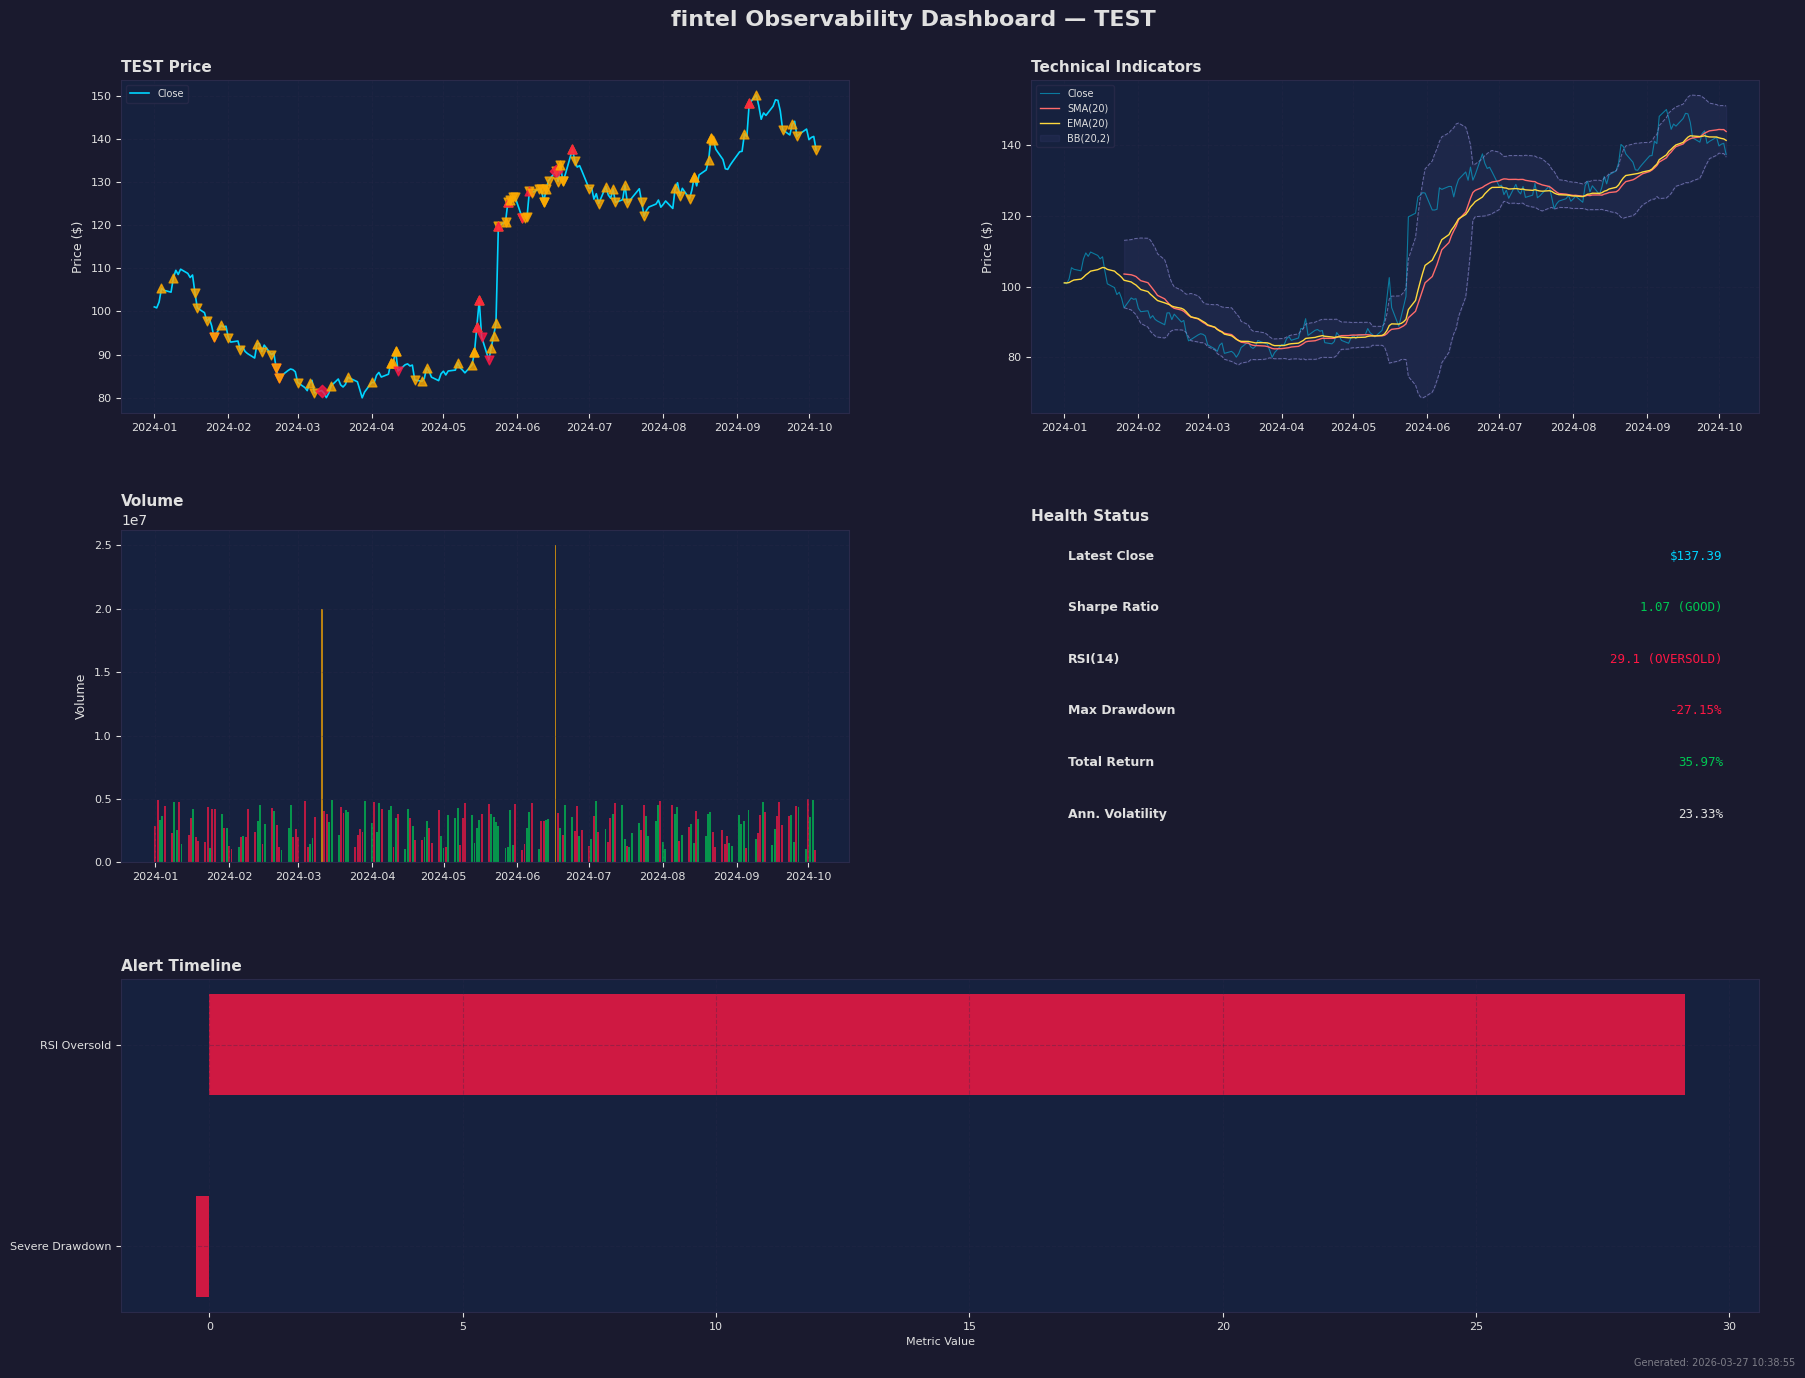

In [17]:
# =============================================================================
# Test 8: Dashboard — Render with synthetic data
# =============================================================================
print("=" * 60)
print("TEST 8: Dashboard Rendering")
print("=" * 60)

# Gather signals and alerts for the dashboard
detector = SignalDetector(test_data, ticker="TEST")
all_sigs = detector.get_all_signals()
triggered_alerts = alert_engine.evaluate(me)

print(f"Rendering dashboard with {len(all_sigs)} signals and {len(triggered_alerts)} alerts...")

dash = Dashboard(
    ticker="TEST",
    data=test_data,
    metrics_engine=me,
    signals=all_sigs,
    alerts=triggered_alerts
)

fig = dash.render()

In [18]:
# =============================================================================
# Test 9: Dashboard — Error Handling
# =============================================================================
print("=" * 60)
print("TEST 9: Dashboard — Error Handling")
print("=" * 60)

# Test: Invalid ticker
try:
    Dashboard("", test_data, me)
except InvalidParameterError as e:
    print(f"\n[PASS] Empty ticker: {e}")

# Test: Invalid MetricsEngine
try:
    Dashboard("TEST", test_data, "not_an_engine")
except DataValidationError as e:
    print(f"[PASS] Invalid MetricsEngine: {e}")

# Test: Correlation heatmap with < 2 tickers
try:
    Dashboard.plot_correlation_heatmap({"AAPL": test_data})
except InvalidParameterError as e:
    print(f"[PASS] Heatmap with < 2 tickers: {e}")

# Test: Correlation heatmap with invalid data
try:
    Dashboard.plot_correlation_heatmap({"A": pd.DataFrame(), "B": test_data})
except DataValidationError as e:
    print(f"[PASS] Heatmap with bad data: {e}")

print("\nAll dashboard error handling tests passed!")

TEST 9: Dashboard — Error Handling

[PASS] Empty ticker: ticker must be a non-empty string.
[PASS] Invalid MetricsEngine: Expected MetricsEngine, got str
[PASS] Heatmap with < 2 tickers: data_dict must be a dict with at least 2 tickers.
[PASS] Heatmap with bad data: Error with ticker 'A': DataFrame is empty. Cannot perform analysis on empty data.

All dashboard error handling tests passed!


---
## Section 7: Examples & Use Cases

The five examples below are small, self-contained, and meant to be read independently. Each demonstrates a single capability of the package so that a new user can copy any one into a Python session and run it without context.

The synthetic data fixture defined in Section 7 (`test_data`) is reused throughout so the examples are deterministic.


### Example 1 — Detect Anomalies on a Single Asset

**Use case:** *I have OHLCV data for one stock and want to know which days were statistically unusual.*

This example runs all four detectors with default thresholds and reports the highest-severity signals first.


In [ ]:
# Example 1 — Single-asset anomaly detection
detector = SignalDetector(test_data, ticker="EXAMPLE-1")
signals = detector.get_all_signals()

# Filter to critical-severity only
critical = [s for s in signals if s.severity == "critical"]
print(f"Total signals: {len(signals)}  |  Critical: {len(critical)}")
for s in critical[:5]:
    print("  ", s)


### Example 2 — Compute Risk Metrics

**Use case:** *I want a single readout of the risk profile of a position — return, drawdown, volatility, Sharpe.*

`MetricsEngine.compute_summary()` produces a dictionary suitable for logging, dashboards, or JSON serialisation.


In [ ]:
# Example 2 — Portfolio risk summary
me = MetricsEngine(test_data)
summary = me.compute_summary()

# Pretty-print
print(f"{'Metric':<25} Value")
print("-" * 50)
for k, v in summary.items():
    if isinstance(v, float):
        print(f"{k:<25} {v:>12.4f}")
    else:
        print(f"{k:<25} {v}")


### Example 3 — Custom Alert Rules

**Use case:** *I want to be notified when specific risk thresholds are breached on a position.*

Rules are registered by name, target metric, condition (`above` / `below`), threshold value, and severity. The engine evaluates all rules against a `MetricsEngine` and returns a list of triggered `Alert` objects.


In [ ]:
# Example 3 — Defining and evaluating custom alert rules
ae = AlertEngine()

# Conservative risk profile
ae.add_rule("RSI Oversold",        "rsi",           "below", 30,    "critical")
ae.add_rule("RSI Overbought",      "rsi",           "above", 70,    "warning")
ae.add_rule("Drawdown Limit",      "max_drawdown",  "below", -0.10, "critical")
ae.add_rule("Volatility Ceiling",  "volatility",    "above", 0.35,  "warning")
ae.add_rule("Negative Return",     "total_return",  "below", 0.0,   "info")

triggered = ae.evaluate(MetricsEngine(test_data))
print(ae.summary())


### Example 4 — Service-Level Objectives

**Use case:** *I want to express portfolio targets as SLOs — "Sharpe must stay above 1.0", "Drawdown must remain shallower than 15%" — and check whether each is met.*

Each SLO returns a structured result with current value, target, and margin of compliance.


In [ ]:
# Example 4 — SLO governance
slos = [
    SLO("Min Sharpe",        "sharpe_ratio", "above", 1.0),
    SLO("Drawdown Budget",   "max_drawdown", "above", -0.15),  # 'above -0.15' means 'no worse than -15%'
    SLO("RSI Health Floor",  "rsi",          "above", 25),
]

print(f"{'SLO':<22} {'Status':<8} {'Current':>10} {'Target':>10} {'Margin':>10}")
print("-" * 64)
me = MetricsEngine(test_data)
for slo in slos:
    r = slo.check(me)
    print(f"{r['slo_name']:<22} {r['status']:<8} {r['current_value']:>10.4f} {r['target']:>10.4f} {r['margin']:>+10.4f}")


### Example 5 — Multi-Asset Correlation

**Use case:** *I have OHLCV data for several tickers and want to see how their returns co-move.*

`Dashboard.plot_correlation_heatmap()` is a static method — no `Dashboard` instance is required.


In [ ]:
# Example 5 — Multi-asset correlation heatmap (uses synthetic test_data twice for demo;
# in practice you would supply distinct DataFrames per ticker).
import numpy as np

np.random.seed(7)
# Build a second synthetic series with partial correlation to test_data
shock = np.random.normal(0, 0.015, len(test_data))
data2 = test_data.copy()
data2["Close"] = test_data["Close"].values * (1 + shock).cumprod()
data2["Open"]  = data2["Close"] * (1 + np.random.uniform(-0.005, 0.005, len(data2)))
data2["High"]  = data2["Close"] * (1 + np.random.uniform(0, 0.02, len(data2)))
data2["Low"]   = data2["Close"] * (1 - np.random.uniform(0, 0.02, len(data2)))

basket = {"ASSET-A": test_data, "ASSET-B": data2}
Dashboard.plot_correlation_heatmap(basket)


### Recap: When to Use Each Module

| Goal | Reach for |
|---|---|
| "Which days were unusual?" | `SignalDetector` (Example 1) |
| "What is the risk profile?" | `MetricsEngine.compute_summary()` (Example 2) |
| "Notify me on breaches" | `AlertEngine` with custom rules (Example 3) |
| "Track performance targets" | `SLO` (Example 4) |
| "See it all at once" | `Dashboard.render()` (Section 8 — full demo) |
| "Compare multiple assets" | `Dashboard.plot_correlation_heatmap` (Example 5) |


---
## Section 8: Full Live Demo — Real Stock Analysis

Now we demonstrate **fintel** with real market data from Yahoo Finance. We will:
1. Download 1 year of OHLCV data for **AAPL**, **GOOGL**, and **MSFT**
2. Run signal detection on AAPL
3. Compute all metrics
4. Set up alert rules and SLOs
5. Render the full observability dashboard
6. Generate a multi-asset correlation heatmap

In [19]:
# =============================================================================
# Step 1: Download real stock data using yfinance
# =============================================================================

tickers = ["AAPL", "GOOGL", "MSFT"]
end_date = datetime.now()
start_date = end_date - timedelta(days=365)

print(f"Downloading data from {start_date.date()} to {end_date.date()}...")

data_dict = {}
for ticker in tickers:
    try:
        df = yf.download(ticker, start=start_date, end=end_date, progress=False)
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)
        data_dict[ticker] = df
        print(f"  {ticker}: {len(df)} trading days downloaded")
    except Exception as e:
        print(f"  {ticker}: Failed to download — {e}")

# Use AAPL as the primary analysis target
aapl_data = data_dict["AAPL"]
print(f"\nAAPL data preview:")
aapl_data.tail()

  AAPL: 252 trading days downloaded
  GOOGL: 252 trading days downloaded
  MSFT: 252 trading days downloaded

AAPL data preview:


Price,Close,High,Low,Open,Volume
Date,,,,,
2026-03-23,251.490005,254.600006,250.279999,253.970001,40546100
2026-03-24,251.639999,254.830002,249.550003,250.350006,45152300
2026-03-25,252.619995,255.000000,251.600006,254.100006,28476700
2026-03-26,252.889999,257.000000,250.770004,252.119995,41702500
2026-03-27,253.330093,255.492996,252.780106,253.910004,10388823


In [20]:
# =============================================================================
# Step 2: Run Signal Detection on AAPL
# =============================================================================

print("Running signal detection on AAPL...\n")

aapl_detector = SignalDetector(aapl_data, ticker="AAPL")
aapl_signals = aapl_detector.get_all_signals()

print(f"Total signals detected: {len(aapl_signals)}")

# Break down by type
signals_df = aapl_detector.signals_to_dataframe()
if not signals_df.empty:
    print(f"\nSignals by type:")
    print(signals_df["signal_type"].value_counts().to_string())
    print(f"\nSignals by severity:")
    print(signals_df["severity"].value_counts().to_string())
    print(f"\nMost recent signals:")
    print(signals_df.tail(5).to_string())

Running signal detection on AAPL...

Total signals detected: 56

Signals by type:
signal_type
breakout_upper      20
volatility_spike     9
gap_up               8
breakout_lower       8
gap_down             7
volume_surge         4

Signals by severity:
severity
warning     33
critical    23

Most recent signals:
   ticker     signal_type  timestamp  severity         value     threshold                                                                metadata
51   AAPL  breakout_upper 2026-02-02   warning  2.697576e+02  2.696345e+02                            {'band': 'upper', 'sma': np.float64(257.36)}
52   AAPL  breakout_upper 2026-02-04   warning  2.762315e+02  2.732804e+02                            {'band': 'upper', 'sma': np.float64(258.18)}
53   AAPL  breakout_lower 2026-03-13  critical  2.501200e+02  2.509501e+02                            {'band': 'lower', 'sma': np.float64(262.75)}
54   AAPL    volume_surge 2026-03-20   warning  8.833110e+07  8.298683e+07  {'multiplier': np.flo

In [21]:
# =============================================================================
# Step 3: Compute Metrics for AAPL
# =============================================================================

print("Computing metrics for AAPL...\n")

aapl_metrics = MetricsEngine(aapl_data)
aapl_summary = aapl_metrics.compute_summary()

print("AAPL Metrics Summary:")
print("-" * 40)
for k, v in aapl_summary.items():
    if isinstance(v, float):
        print(f"  {k:25s}: {v:.4f}")
    else:
        print(f"  {k:25s}: {v}")

Computing metrics for AAPL...

AAPL Metrics Summary:
----------------------------------------
  latest_close             : 253.3301
  sma_20                   : 255.6025
  ema_20                   : 255.3805
  rsi_14                   : 38.0258
  sharpe_ratio             : 0.4985
  max_drawdown             : -0.2299
  max_drawdown_peak        : 2025-04-02
  max_drawdown_trough      : 2025-04-08
  annualized_volatility    : 0.1541
  total_return             : 0.1366


In [22]:
# =============================================================================
# Step 4: Set up Alert Rules and SLOs
# =============================================================================

print("Setting up alert rules and SLOs for AAPL...\n")

aapl_alerts = AlertEngine()
aapl_alerts.add_rule("RSI Oversold", "rsi", "below", 30, "critical")
aapl_alerts.add_rule("RSI Overbought", "rsi", "above", 70, "warning")
aapl_alerts.add_rule("High Volatility", "volatility", "above", 0.40, "warning")
aapl_alerts.add_rule("Severe Drawdown", "max_drawdown", "below", -0.15, "critical")
aapl_alerts.add_rule("Negative Return", "total_return", "below", 0.0, "info")

triggered = aapl_alerts.evaluate(aapl_metrics)
print(aapl_alerts.summary())

# SLO checks
print("\n--- SLO Status ---")
slos = [
    SLO("Min Sharpe Target", "sharpe_ratio", "above", 0.5),
    SLO("Drawdown Budget", "max_drawdown", "above", -0.20),
    SLO("RSI Health Floor", "rsi", "above", 25),
]

for slo in slos:
    result = slo.check(aapl_metrics)
    icon = "PASS" if result["met"] else "FAIL"
    print(f"  [{icon}] {slo.name}: current={result['current_value']:.4f}, target={result['target']:.4f}, margin={result['margin']:.4f}")

Setting up alert rules and SLOs for AAPL...

=== ALERT SUMMARY (1 triggered) ===
  [!!!] Severe Drawdown: max_drawdown is -0.2299, which is below threshold -0.15

--- SLO Status ---
  [FAIL] Min Sharpe Target: current=0.4985, target=0.5000, margin=-0.0015
  [FAIL] Drawdown Budget: current=-0.2299, target=-0.2000, margin=-0.0299
  [PASS] RSI Health Floor: current=38.0258, target=25.0000, margin=13.0258


Rendering AAPL Observability Dashboard...



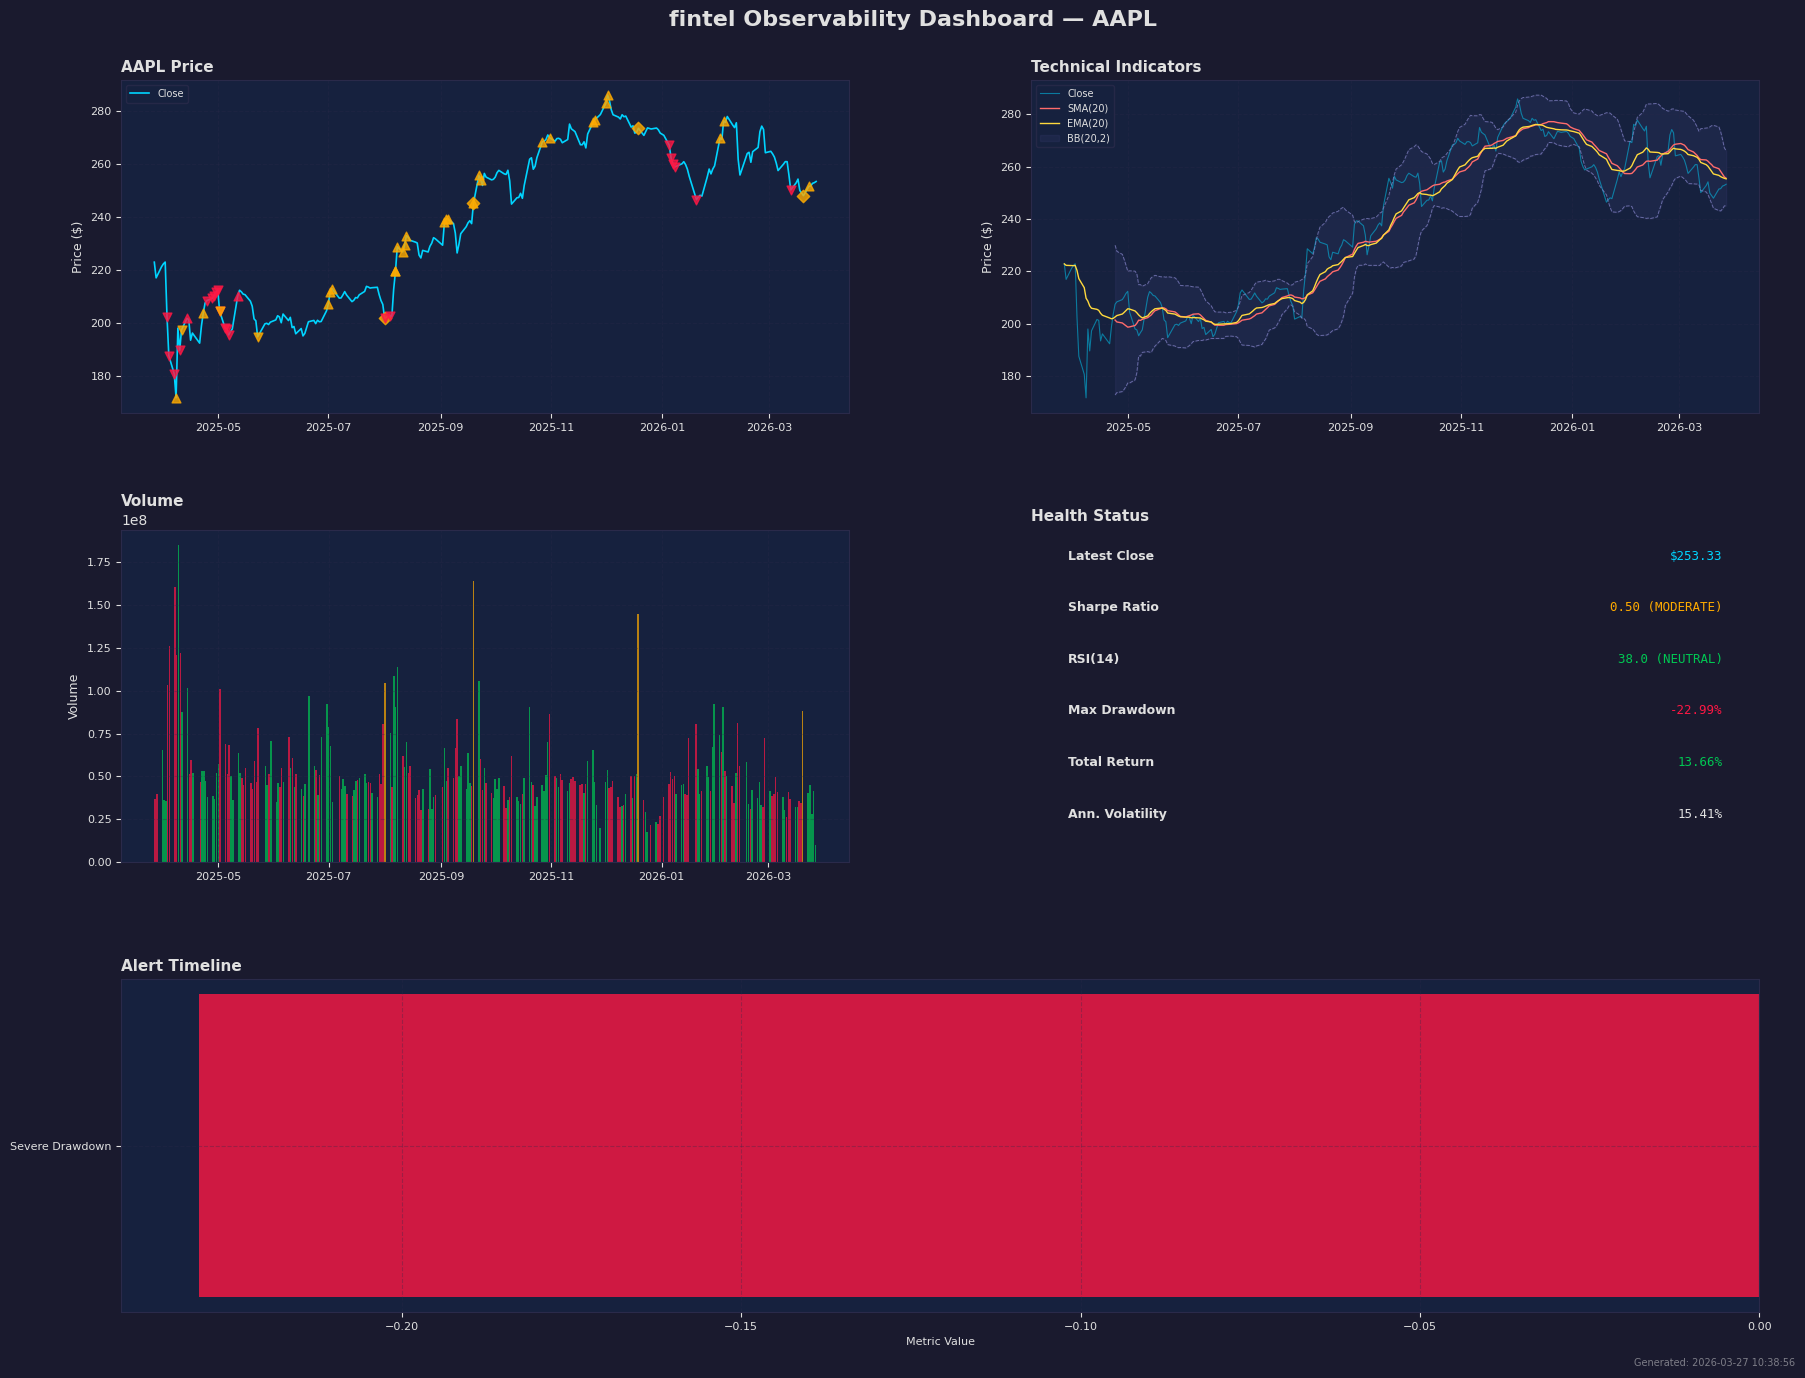

In [23]:
# =============================================================================
# Step 5: Render Full AAPL Observability Dashboard
# =============================================================================

print("Rendering AAPL Observability Dashboard...\n")

aapl_dash = Dashboard(
    ticker="AAPL",
    data=aapl_data,
    metrics_engine=aapl_metrics,
    signals=aapl_signals,
    alerts=triggered
)

fig = aapl_dash.render()

Generating correlation heatmap for AAPL, GOOGL, MSFT...



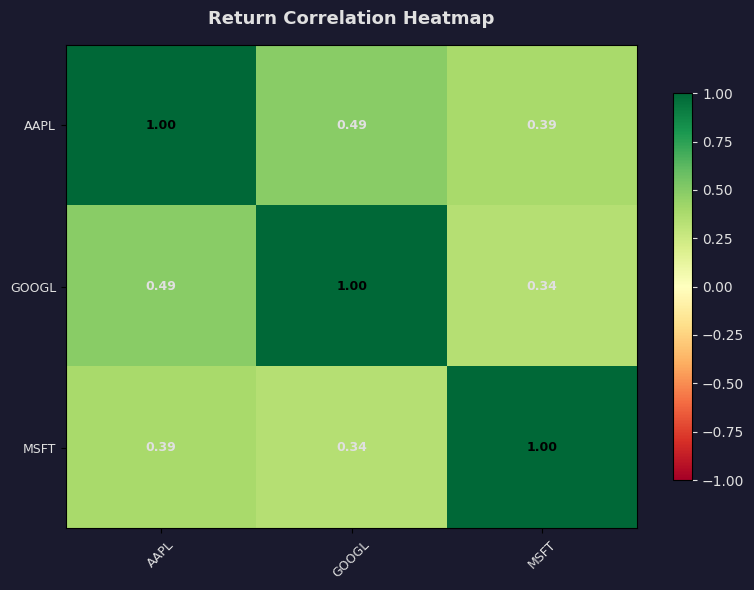

In [24]:
# =============================================================================
# Step 6: Multi-Asset Correlation Heatmap
# =============================================================================

print("Generating correlation heatmap for AAPL, GOOGL, MSFT...\n")

fig_corr = Dashboard.plot_correlation_heatmap(data_dict)

---
## Section 9: Design Decisions & Conclusion

### Design Decisions

1. **OpenTelemetry Conceptual Mapping**: We chose to map financial analysis concepts to observability engineering patterns because both domains share a fundamental challenge — monitoring complex, dynamic systems and detecting anomalies in real time. This unique angle differentiates our package from typical stock analysis tools.

2. **Class-Based Architecture**: Each module uses OOP with well-defined classes (`SignalDetector`, `MetricsEngine`, `AlertEngine`, `Dashboard`) because:
   - They encapsulate state (e.g., cached metrics, accumulated signals)
   - They enable composition (Dashboard takes a MetricsEngine as input)
   - They follow Python conventions for packages

3. **Custom Exception Hierarchy**: We defined `FintelError` as a base class with specific subclasses (`DataValidationError`, `InsufficientDataError`, `InvalidParameterError`) so users can catch errors at the right granularity — either all fintel errors or specific categories.

4. **Metric Caching**: The `MetricsEngine` caches computed results in a dictionary to avoid redundant calculations when the same metric is accessed multiple times (e.g., SMA is used by both Bollinger Bands and the dashboard).

5. **Dark Theme Dashboard**: We styled the dashboard after Grafana's dark theme because:
   - It reinforces the observability narrative
   - It provides better contrast for financial data visualization
   - It demonstrates advanced matplotlib customization skills

6. **Signal Severity Levels**: Using info/warning/critical (matching OTel conventions) allows users to filter and prioritize market events, just as SREs prioritize production incidents.

### Challenges Faced

- **yfinance column format**: yfinance sometimes returns MultiIndex columns when downloading a single ticker. We handle this by flattening columns in `validate_ohlcv()`.
- **NaN handling in rolling calculations**: Early rows in rolling windows produce NaN values. We consistently use `.dropna()` or `.notna()` masks to handle these edge cases.
- **RSI division by zero**: When all price changes are in the same direction, the average loss or gain can be zero. We use `np.where` to handle this safely.
- **matplotlib dark theming**: Consistently theming all axes, legends, colorbars, and text required a systematic `_style_ax` helper method.

### Package Utilization of Allowed Libraries

| Library | Usage |
|---|---|
| **pandas** | DataFrame operations, rolling windows, time series indexing, pct_change, cummax |
| **numpy** | Random seed for tests, array operations, sqrt, issubdtype, where, statistical functions |
| **matplotlib** | All visualizations — line plots, bar charts, heatmaps, multi-panel GridSpec layouts, custom theming |
| **datetime** | Alert timestamps, date range calculations, timedelta for data download windows |
| **yfinance** | Live OHLCV data download for real stock analysis demo |